In [ ]:
%%capture
!pip install numpyro jax jaxlib funsor -q

In [ ]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.handlers import mask
from numpyro.ops.indexing import Vindex
from numpyro.infer import MCMC, NUTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from google.colab import drive
drive.mount('/content/drive')

print("JAX device:", jax.devices())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JAX device: [CpuDevice(id=0)]


## Marginalized HMM Model
We marginalize out the discrete latent states so NUTS can operate on continuous parameters only (mu, sigma, probs_z).

In [ ]:
def hmm_model_marginalized(sequences, lengths, args):
    num_sequences, max_length, data_dim = sequences.shape
    K = args['h_dim']

    probs_z = numpyro.sample(
        "probs_z",
        dist.Dirichlet(0.9 * jnp.eye(K) + 0.1).to_event(1)
    )
    mu = numpyro.sample(
        "mu",
        dist.Normal(0.0, 1.0).expand([K, data_dim]).to_event(2)
    )
    sigma = numpyro.sample(
        "sigma",
        dist.HalfNormal(1.0).expand([K, data_dim]).to_event(2)
    )

    def forward_one(obs):
        # obs: (T, D)
        log_emit = jnp.stack([
            dist.Normal(mu[k], sigma[k]).log_prob(obs).sum(-1)
            for k in range(K)
        ], axis=-1)  # (T, K)

        log_trans = jnp.log(probs_z + 1e-8)  # (K, K)

        log_alpha = log_emit[0]  # (K,)

        def step(log_alpha, log_emit_t):
            log_alpha_t = log_emit_t + jax.scipy.special.logsumexp(
                log_alpha[:, None] + log_trans, axis=0
            )
            return log_alpha_t, None

        log_alpha_T, _ = jax.lax.scan(step, log_alpha, log_emit[1:])
        return jax.scipy.special.logsumexp(log_alpha_T)

    log_liks = jax.vmap(forward_one)(sequences)
    numpyro.factor("obs", log_liks.sum())

In [ ]:
DATA_DIR  = "/content/drive/MyDrive/Bayesian Final Project/DATA"
MODEL_DIR = "/content/drive/MyDrive/Bayesian Final Project/Model"

iu = pd.read_parquet(os.path.join(DATA_DIR, "instance_usage_training01_parquet.parquet"))

## Build Sequences (4 features, 20 tasks, 100 time steps)
We use 4 core features and 20 tasks. Experiments with 64 tasks showed convergence issues (r_hat > 1.1) due to posterior concentration. 20 tasks achieved full convergence (r_hat ≤ 1.01).

In [ ]:
# 20 tasks, 4 features
FEATURES = ["average_usage_cpus", "average_usage_memory",
            "maximum_usage_cpus", "maximum_usage_memory"]

MAX_LEN  = 100
N_TASKS  = 20
task_seqs = []

for (cid, iidx), grp in iu_sorted.groupby(["collection_id", "instance_index"], sort=False):
    grp = grp.sort_values("start_time")
    if len(grp) < MAX_LEN:
        continue
    obs = grp[FEATURES].values.astype(np.float32)
    obs = np.nan_to_num(obs, nan=0.0)
    obs = (obs - obs.mean(axis=0)) / (obs.std(axis=0) + 1e-8)
    task_seqs.append(obs[:MAX_LEN])
    if len(task_seqs) == N_TASKS:
        break

print(f"Got {len(task_seqs)} tasks")

Got 20 tasks


In [ ]:
sequences_mcmc = jnp.array(np.stack(task_seqs))
lengths_mcmc   = jnp.array([MAX_LEN] * len(task_seqs))
args           = {"h_dim": 3}

kernel = NUTS(hmm_model_marginalized)
mcmc   = MCMC(kernel, num_warmup=500, num_samples=1000, num_chains=1, progress_bar=True)
mcmc.run(jax.random.PRNGKey(0), sequences_mcmc, lengths_mcmc, args)
mcmc.print_summary()

sample: 100%|██████████| 1500/1500 [01:37<00:00, 15.43it/s, 31 steps of size 9.69e-02. acc. prob=0.93]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
     mu[0,0]      0.67      0.01      0.67      0.65      0.69    910.15      1.00
     mu[0,1]      0.67      0.02      0.67      0.65      0.71    892.16      1.00
     mu[0,2]      1.20      0.04      1.20      1.14      1.26    907.62      1.00
     mu[0,3]      0.73      0.01      0.73      0.70      0.75    699.25      1.00
     mu[1,0]     -0.81      0.00     -0.81     -0.81     -0.80   1581.13      1.00
     mu[1,1]     -0.94      0.00     -0.94     -0.94     -0.93   1802.26      1.00
     mu[1,2]     -0.78      0.01     -0.78     -0.79     -0.76    898.15      1.00
     mu[1,3]     -1.01      0.01     -1.01     -1.02     -0.99   1051.71      1.00
     mu[2,0]     -0.43      0.01     -0.43     -0.46     -0.41    965.75      1.00
     mu[2,1]      0.36      0.04      0.36      0.30      0.41    631.99      1.00
     mu[2,2]     -0.19      0.01     -0.19     -0.21     -0.17    780.64      1.00
   

In [ ]:
mcmc_samples = mcmc.get_samples()
with open(f"{MODEL_DIR}/mcmc_samples_20tasks_4feat.pkl", "wb") as f:
    pickle.dump(mcmc_samples, f)
print("Saved.")

Saved.


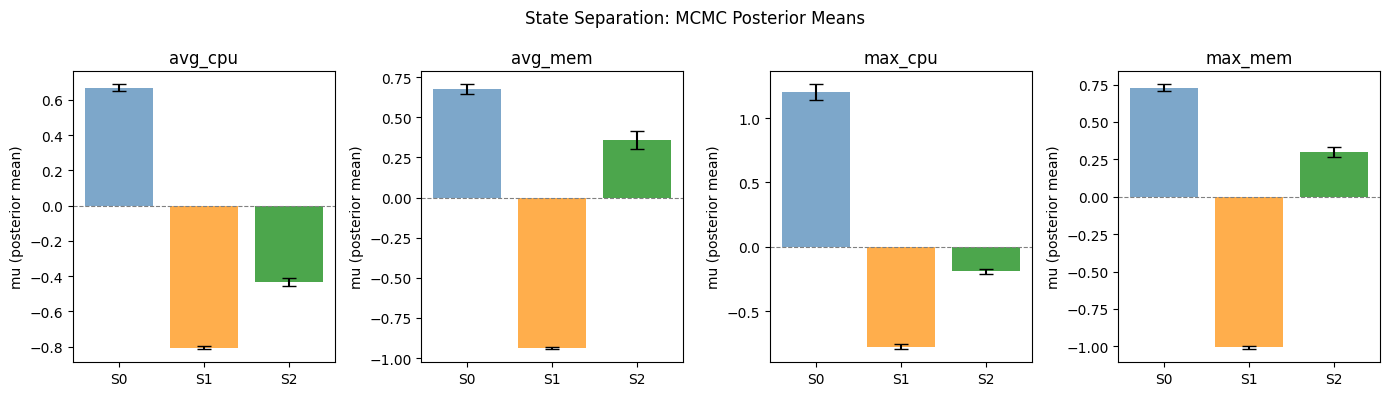

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("State Separation: MCMC Posterior Means", fontsize=12)

mcmc_mu_mean = mcmc_mu.mean(axis=0)  # (3, 4)

for f in range(4):
    ax = axes[f]
    for s in range(3):
        ax.bar(s, mcmc_mu_mean[s, f], color=colors[s],
               alpha=0.7, label=state_names[s])
        # 95% CI
        lo = np.percentile(mcmc_mu[:, s, f], 5)
        hi = np.percentile(mcmc_mu[:, s, f], 95)
        ax.errorbar(s, mcmc_mu_mean[s, f],
                    yerr=[[mcmc_mu_mean[s,f]-lo], [hi-mcmc_mu_mean[s,f]]],
                    fmt='none', color='black', capsize=5)
    ax.set_title(feature_names[f])
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(["S0","S1","S2"])
    ax.set_ylabel("mu (posterior mean)")
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/mcmc_state_separation.png", dpi=150)
plt.show()